# Analisis Sentimen - Balanced Training (Resample)


In [47]:
from pathlib import Path
import ast
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, classification_report, confusion_matrix,
    log_loss, hinge_loss
)
from sklearn.utils import resample

sns.set_theme(style="whitegrid")


In [48]:
# Load dataset stemming
candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
csv_path = None
for candidate in candidates:
    direct = candidate / 'data' / 'prosses' / 'stemming.csv'
    nested = candidate / 'analisis' / 'data' / 'prosses' / 'stemming.csv'
    if direct.exists():
        csv_path = direct
        break
    if nested.exists():
        csv_path = nested
        break

if csv_path is None:
    raise FileNotFoundError('File stemming.csv tidak ditemukan dari direktori kerja saat ini.')

data = pd.read_csv(csv_path, sep=';')

def safe_eval(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

data['stemming'] = data['stemming'].apply(safe_eval)
print(f"Processed dataset aktif: {csv_path}")
print(f"Total data: {len(data)}")

data.head()


Processed dataset aktif: D:\PROYEK TUGAS AKHIR\APP TA\analisis\data\prosses\stemming.csv
Total data: 2175


,stemming,label
0,"[hotel, mudah, temu, jalan, malioboro, karyawa...",Negatif
1,"[lokasi, atas, lokasi, hotel, banyak, toko, to...",Positif
2,"[pengalaman, menginap, tidak, senang, menginap...",Negatif
3,"[lokasi, mudah, temu, makan, lengkap, variasi,...",Positif
4,"[anak, nikmat, menginap, hotel, kolam, renang,...",Positif


In [49]:
# Encoding label -> 0/1 (Negatif/Positif)
def encode_label(v):
    s = str(v).strip().lower()
    if 'positif' in s or s == 'positive' or s == '1':
        return 1
    if 'negatif' in s or s == 'negative' or s == '0':
        return 0
    return np.nan

data['encoded'] = data['label'].apply(encode_label)
data = data.dropna(subset=['encoded']).copy()
data['encoded'] = data['encoded'].astype(int)

print('Distribusi label:')
print(data['encoded'].value_counts().sort_index())


Distribusi label:
encoded
0     185
1    1990
Name: count, dtype: int64


In [50]:
# Split train-test
X = data['stemming']
y = data['encoded']

X_train_tokens, X_test_tokens, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Jumlah data train: {len(X_train_tokens)} | test: {len(X_test_tokens)}')


Jumlah data train: 1740 | test: 435


In [51]:
# TF-IDF dari token hasil preprocessing
try:
    from analisis.vectorizer_identity import identity
except ModuleNotFoundError:
    from vectorizer_identity import identity

tfidf = TfidfVectorizer(
    tokenizer=identity,
    preprocessor=identity,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 3),
    max_df=0.9,
    min_df=2,
    sublinear_tf=True,
    norm='l2'
)

X_train_tfidf = tfidf.fit_transform(X_train_tokens)
X_test_tfidf = tfidf.transform(X_test_tokens)

print('Vocabulary size:', len(tfidf.vocabulary_))
print('Shape train:', X_train_tfidf.shape, '| Shape test:', X_test_tfidf.shape)


Vocabulary size: 5123
Shape train: (1740, 5123) | Shape test: (435, 5123)


In [52]:
from sklearn.utils import resample
import numpy as np

# Upsample kelas minoritas (training saja) agar lebih seimbang
# Catatan: gunakan X_train hasil TF-IDF (sparse) + y_train asli

def upsample_minority_sparse(X, y, random_state=42):
    y_arr = np.asarray(y)
    classes, counts = np.unique(y_arr, return_counts=True)
    if len(classes) < 2:
        return X, y_arr
    maj_class = classes[np.argmax(counts)]
    min_class = classes[np.argmin(counts)]
    idx_maj = np.where(y_arr == maj_class)[0]
    idx_min = np.where(y_arr == min_class)[0]
    if len(idx_min) == 0 or len(idx_maj) == 0:
        return X, y_arr
    idx_min_up = resample(
        idx_min,
        replace=True,
        n_samples=len(idx_maj),
        random_state=random_state
    )
    idx_bal = np.concatenate([idx_maj, idx_min_up])
    rng = np.random.RandomState(random_state)
    rng.shuffle(idx_bal)
    return X[idx_bal], y_arr[idx_bal]

X_train_bal, y_train_bal = upsample_minority_sparse(X_train_tfidf, y_train, random_state=42)

print('Distribusi kelas (train asli):', np.bincount(np.asarray(y_train)))
print('Distribusi kelas (train balanced):', np.bincount(np.asarray(y_train_bal)))


Distribusi kelas (train asli): [ 148 1592]
Distribusi kelas (train balanced): [1592 1592]


## Visualisasi Distribusi Kelas Setelah Resampling


In [ ]:
# Visualisasi distribusi kelas train sebelum dan sesudah resampling
label_map = {0: 'Negatif', 1: 'Positif'}
kelas = [0, 1]

train_asli = pd.Series(np.asarray(y_train)).value_counts().reindex(kelas, fill_value=0)
train_balanced = pd.Series(np.asarray(y_train_bal)).value_counts().reindex(kelas, fill_value=0)

df_distribusi = pd.DataFrame({
    'Train Asli': train_asli.values,
    'Train Balanced': train_balanced.values
}, index=[label_map[k] for k in kelas])

print(df_distribusi)

ax = df_distribusi.plot(
    kind='bar',
    figsize=(7, 4.5),
    color=['#3498db', '#2ecc71'],
    width=0.75
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.title('Perbandingan Distribusi Kelas Data Latih')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.legend(title='Kondisi Data')
plt.tight_layout()
plt.show()


## Visualisasi Data Latih Setelah Balanced


In [ ]:
# Visualisasi khusus distribusi data latih setelah resampling
balanced_counts = pd.Series(np.asarray(y_train_bal)).value_counts().reindex([1, 0], fill_value=0)
balanced_counts.index = ['Positif', 'Negatif']
balanced_percent = (balanced_counts / balanced_counts.sum() * 100).round(2)

df_balanced = pd.DataFrame({
    'Jumlah': balanced_counts,
    'Persentase (%)': balanced_percent
})
print(df_balanced)

warna = ['#2ecc71', '#e74c3c']
plt.figure(figsize=(5, 4))
bars = plt.bar(balanced_counts.index, balanced_counts.values, color=warna, width=0.6)

for bar, jumlah, pct in zip(bars, balanced_counts.values, balanced_percent.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(balanced_counts.values) * 0.02,
        f'{jumlah}\n({pct:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Distribusi Data Latih Setelah Resampling')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.ylim(0, max(balanced_counts.values) * 1.15)
plt.tight_layout()
plt.show()


NAIVE BAYES

In [54]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import ComplementNB

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

param_grid = {
    'alpha': [0.01, 0.05, 0.1, 0.5, 1.0, 10, 1000]
}

grid = GridSearchCV(
    ComplementNB(),
    param_grid,
    cv=5,
    scoring='f1_macro'
)


In [55]:
grid.fit(X_train_bal, y_train_bal)

,estimator,ComplementNB()
,param_grid,"{'alpha': [0.01, 0.05, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.01


In [56]:

nbm = grid.best_estimator_


In [57]:
print("Alpha terbaik:", grid.best_params_)
print("Score terbaik:", grid.best_score_)
print("Best estimator:", grid.best_estimator_)


Alpha terbaik: {'alpha': 0.01}
Score terbaik: 0.9830348899057887
Best estimator: ComplementNB(alpha=0.01)


TRAINING EVALUATION
Accuracy (Train): 0.9937185929648241

Classification Report (Train):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1592
           1       1.00      0.99      0.99      1592

    accuracy                           0.99      3184
   macro avg       0.99      0.99      0.99      3184
weighted avg       0.99      0.99      0.99      3184



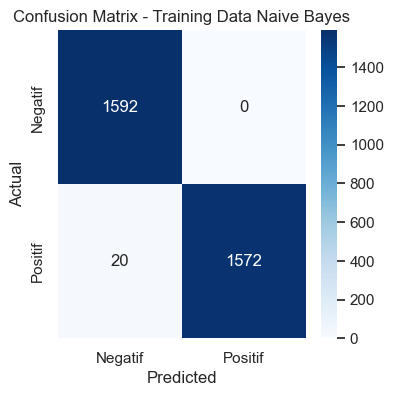

In [58]:
# Evaluasi Naive Bayes
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, hinge_loss
# Prediksi data testing
print("TRAINING EVALUATION")
y_pred = nbm.predict(X_train_bal)
train_acc = accuracy_score(y_train_bal, y_pred)

print("Accuracy (Train):", train_acc)
print("\nClassification Report (Train):")
print(classification_report(y_train_bal, y_pred))
#confusing matrix
cm = confusion_matrix(y_train_bal, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Training Data Naive Bayes")
plt.show()


TESTING EVALUATION (NAIVE BAYES)
Accuracy  : 0.9402
Precision : 0.9450
Recall    : 0.9402
F1-Score  : 0.9422
Log Loss  : 0.1769
Balanced Acc: 0.8448

Classification Report (Test):
              precision    recall  f1-score   support

     Negatif       0.63      0.73      0.68        37
     Positif       0.97      0.96      0.97       398

    accuracy                           0.94       435
   macro avg       0.80      0.84      0.82       435
weighted avg       0.95      0.94      0.94       435



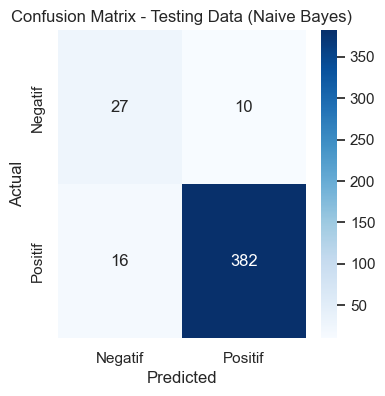

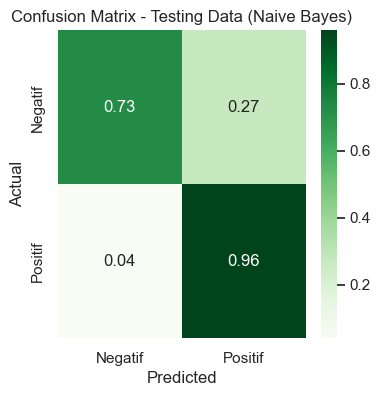

In [31]:
from sklearn.metrics import (accuracy_score,balanced_accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,log_loss)
# Prediksi
y_pred = nbm.predict(X_test_tfidf)
y_proba = nbm.predict_proba(X_test_tfidf)
# Evaluasi
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')
loss = log_loss(y_test, y_proba)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print("TESTING EVALUATION (NAIVE BAYES)")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"Log Loss  : {loss:.4f}")
print(f"Balanced Acc: {bal_acc:.4f}")
print("\nClassification Report (Test):")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negatif", "Positif"]
))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data (Naive Bayes)")
plt.show()
# Confusion Matrix (normalized by true label)
plt.figure(figsize=(4,4))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data (Naive Bayes)")
plt.show()


SUPPORT VECTOR MACHINE

In [32]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC

param_grid = {
    "C": [0.01, 0.05, 0.1, 0.5, 1, 2]
}

svm = LinearSVC(
    class_weight="balanced",
    max_iter=15000,
    random_state=42,
    dual=False
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=1
)


In [38]:
grid.fit(X_train_bal, y_train_bal)

,estimator,LinearSVC(cla...ndom_state=42)
,param_grid,"{'C': [0.01, 0.05, ...]}"
,scoring,'f1_macro'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [39]:
svm = grid.best_estimator_


In [40]:
print("Best C:", grid.best_params_)
print("Best CV F1_macro:", grid.best_score_)
print("Best estimator:", grid.best_estimator_)


Best C: {'C': 2}
Best CV F1_macro: 0.9880630020091508
Best estimator: LinearSVC(C=2, class_weight='balanced', dual=False, max_iter=15000,
          random_state=42)


TRAINING EVALUATION
Accuracy (Train): 1.0
Hinge Loss (Train): 0.028514689861571112

Classification Report (Train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00      1592

    accuracy                           1.00      1740
   macro avg       1.00      1.00      1.00      1740
weighted avg       1.00      1.00      1.00      1740



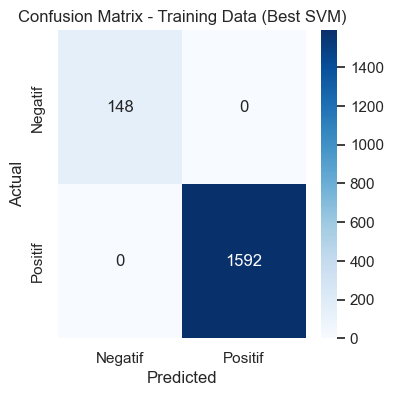

In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, hinge_loss
# Prediksi data testing
print("TRAINING EVALUATION")

y_pred = svm.predict(X_train_tfidf)
y_score = svm.decision_function(X_train_tfidf)

train_acc = accuracy_score(y_train, y_pred)
train_loss = hinge_loss(y_train, y_score)

print("Accuracy (Train):", train_acc)
print("Hinge Loss (Train):", train_loss)
print("\nClassification Report (Train):")
print(classification_report(y_train, y_pred))
#confusing matrix
cm = confusion_matrix(y_train, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Training Data (Best SVM)")
plt.show()


TESTING EVALUATION (SVM)
Accuracy   : 0.9540
Precision  : 0.9514
Recall     : 0.9540
F1-Score   : 0.9522
Hinge Loss : 0.1565
Balanced Acc: 0.8155

Classification Report (Test):
              precision    recall  f1-score   support

     Negatif       0.77      0.65      0.71        37
     Positif       0.97      0.98      0.98       398

    accuracy                           0.95       435
   macro avg       0.87      0.82      0.84       435
weighted avg       0.95      0.95      0.95       435



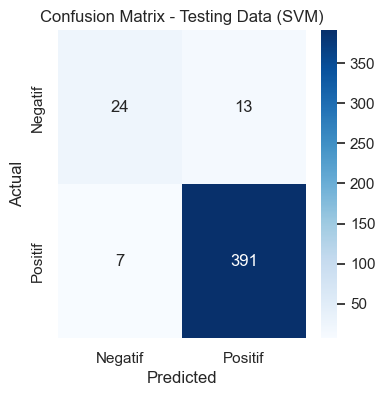

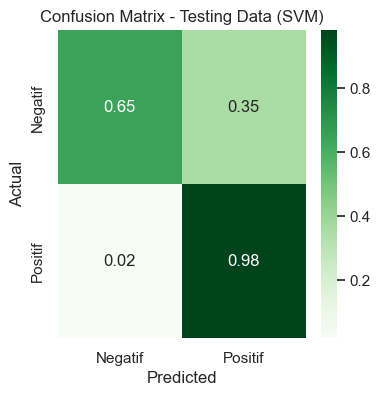

In [42]:
from sklearn.metrics import (accuracy_score,balanced_accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,hinge_loss)

print("TESTING EVALUATION (SVM)")
y_pred = svm.predict(X_test_tfidf)
y_score = svm.decision_function(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
loss = hinge_loss(y_test, y_score)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print(f"Accuracy   : {acc:.4f}")
print(f"Precision  : {prec:.4f}")
print(f"Recall     : {rec:.4f}")
print(f"F1-Score   : {f1:.4f}")
print(f"Hinge Loss : {loss:.4f}")
print(f"Balanced Acc: {bal_acc:.4f}")

print("\nClassification Report (Test):")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negatif", "Positif"]))

cm = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data (SVM)")
plt.show()
plt.figure(figsize=(4,4))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Testing Data (SVM)")
plt.show()


Download Model TF-IDF, NB dan SVM

In [ ]:
# import ast
# import json
# import pickle
# from pathlib import Path

# import numpy as np
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     balanced_accuracy_score,
#     log_loss,
#     hinge_loss
# )
# from sklearn.model_selection import train_test_split
# from sklearn.naive_bayes import ComplementNB
# from sklearn.svm import LinearSVC
# from sklearn.utils import resample

# try:
#     from analisis.vectorizer_identity import identity
# except ModuleNotFoundError:
#     from vectorizer_identity import identity

# # 1) Siapkan data dari hasil pipeline in-memory
# export_df = data.copy()

# def safe_eval_export(x):
#     if isinstance(x, list):
#         return x
#     if isinstance(x, str):
#         try:
#             v = ast.literal_eval(x)
#             return v if isinstance(v, list) else []
#         except Exception:
#             return []
#     return []

# export_df['stemming'] = export_df['stemming'].apply(safe_eval_export)
# export_df = export_df[export_df['stemming'].apply(lambda v: isinstance(v, list) and len(v) > 0)].copy()

# # 2) Label -> encoded
# label_col = 'label'
# label_map = {'Negatif': 0, 'Positif': 1}

# export_df = export_df[export_df[label_col].isin(label_map.keys())].copy()
# export_df['encoded'] = export_df[label_col].map(label_map)

# X_all = export_df['stemming']
# y_all = export_df['encoded'].astype(int)

# X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
#     X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
# )

# # 3) Konfigurasi TF-IDF (sama dengan analisis utama)
# tfidf_cfg = dict(
#     tokenizer=identity,
#     preprocessor=identity,
#     token_pattern=None,
#     lowercase=False,
#     ngram_range=(1, 3),
#     max_df=0.9,
#     min_df=2,
#     sublinear_tf=True,
#     norm='l2'
# )

# tfidf_export = TfidfVectorizer(**tfidf_cfg)
# Xtr_exp = tfidf_export.fit_transform(X_train_exp)
# Xte_exp = tfidf_export.transform(X_test_exp)

# # 4) Balance training set (resample)
# def upsample_minority_sparse(X, y, random_state=42):
#     y_arr = np.asarray(y)
#     classes, counts = np.unique(y_arr, return_counts=True)
#     if len(classes) < 2:
#         return X, y_arr
#     maj_class = classes[np.argmax(counts)]
#     min_class = classes[np.argmin(counts)]
#     idx_maj = np.where(y_arr == maj_class)[0]
#     idx_min = np.where(y_arr == min_class)[0]
#     idx_min_up = resample(idx_min, replace=True, n_samples=len(idx_maj), random_state=random_state)
#     idx_bal = np.concatenate([idx_maj, idx_min_up])
#     rng = np.random.RandomState(random_state)
#     rng.shuffle(idx_bal)
#     return X[idx_bal], y_arr[idx_bal]

# Xtr_bal, ytr_bal = upsample_minority_sparse(Xtr_exp, y_train_exp, random_state=42)

# # 5) Train model fixed params (hasil terbaik balanced)
# nb_export = ComplementNB(alpha=0.01)
# nb_export.fit(Xtr_bal, ytr_bal)
# nb_pred_exp = nb_export.predict(Xte_exp)
# nb_proba_exp = nb_export.predict_proba(Xte_exp)

# svm_export = LinearSVC(
#     C=2,
#     class_weight='balanced',
#     max_iter=15000,
#     dual=False,
#     random_state=42
# )
# svm_export.fit(Xtr_bal, ytr_bal)
# svm_pred_exp = svm_export.predict(Xte_exp)
# svm_score_exp = svm_export.decision_function(Xte_exp)

# # 6) Simpan artifacts (balanced)
# artifacts_dir = Path('model_machine_balance')
# artifacts_dir.mkdir(parents=True, exist_ok=True)

# with open(artifacts_dir / 'vectorizer_balance.pkl', 'wb') as f:
#     pickle.dump(tfidf_export, f, protocol=pickle.HIGHEST_PROTOCOL)

# with open(artifacts_dir / 'naive_bayes_model_balance.pkl', 'wb') as f:
#     pickle.dump(nb_export, f, protocol=pickle.HIGHEST_PROTOCOL)

# with open(artifacts_dir / 'SVM_model_balance.pkl', 'wb') as f:
#     pickle.dump(svm_export, f, protocol=pickle.HIGHEST_PROTOCOL)

# metrics_export = {
#     'nb': {
#         'alpha': 0.01,
#         'accuracy': float(accuracy_score(y_test_exp, nb_pred_exp)),
#         'precision_weighted': float(precision_score(y_test_exp, nb_pred_exp, average='weighted')),
#         'recall_weighted': float(recall_score(y_test_exp, nb_pred_exp, average='weighted')),
#         'f1_weighted': float(f1_score(y_test_exp, nb_pred_exp, average='weighted')),
#         'f1_macro': float(f1_score(y_test_exp, nb_pred_exp, average='macro')),
#         'balanced_accuracy': float(balanced_accuracy_score(y_test_exp, nb_pred_exp)),
#         'log_loss': float(log_loss(y_test_exp, nb_proba_exp))
#     },
#     'svm': {
#         'C': 2,
#         'accuracy': float(accuracy_score(y_test_exp, svm_pred_exp)),
#         'precision_weighted': float(precision_score(y_test_exp, svm_pred_exp, average='weighted')),
#         'recall_weighted': float(recall_score(y_test_exp, svm_pred_exp, average='weighted')),
#         'f1_weighted': float(f1_score(y_test_exp, svm_pred_exp, average='weighted')),
#         'f1_macro': float(f1_score(y_test_exp, svm_pred_exp, average='macro')),
#         'balanced_accuracy': float(balanced_accuracy_score(y_test_exp, svm_pred_exp)),
#         'hinge_loss': float(hinge_loss(y_test_exp, svm_score_exp))
#     },
#     'tfidf_vocab_size': int(len(tfidf_export.vocabulary_)),
#     'balanced': True
# }

# with open(artifacts_dir / 'metrics_nb_svm_balance.json', 'w', encoding='utf-8') as f:
#     json.dump(metrics_export, f, indent=2, ensure_ascii=False)

# print('Artifacts balanced berhasil dibuat di:', artifacts_dir.resolve())
# print(json.dumps(metrics_export, indent=2, ensure_ascii=False))



Artifacts balanced berhasil dibuat di: D:\PROYEK TUGAS AKHIR\APP TA\analisis\model_machine_balance
{
  "nb": {
    "alpha": 0.01,
    "accuracy": 0.9402298850574713,
    "precision_weighted": 0.945010337735736,
    "recall_weighted": 0.9402298850574713,
    "f1_weighted": 0.9422442892477813,
    "f1_macro": 0.8210443037974684,
    "balanced_accuracy": 0.844764362352302,
    "log_loss": 0.17690452134513243
  },
  "svm": {
    "C": 2,
    "accuracy": 0.9540229885057471,
    "precision_weighted": 0.9513522542465592,
    "recall_weighted": 0.9540229885057471,
    "f1_weighted": 0.9521665747733439,
    "f1_macro": 0.8404723485404137,
    "balanced_accuracy": 0.815530354475078,
    "hinge_loss": 0.1564654102573066
  },
  "tfidf_vocab_size": 5123,
  "balanced": true
}
